In [204]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [205]:
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
orders_items = pd.read_csv("olist_order_items_dataset.csv")
order_payment = pd.read_csv("olist_order_payments_dataset.csv")
order_review = pd.read_csv("olist_order_reviews_dataset.csv")
order_dataset = pd.read_csv("olist_orders_dataset.csv")
product_dataset = pd.read_csv("olist_products_dataset.csv")
sellers_dataset = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

In [206]:
print("customers:",customers.shape)
print("geolocation:",geolocation.shape)
print("orders_items:",orders_items.shape)
print("Order Payments:", order_payment.shape)
print("Order Reviews:", order_review.shape)
print("Orders:", order_dataset.shape)
print("Products:", product_dataset.shape)
print("Sellers:", sellers_dataset.shape)
print("Category Translation:", category_translation.shape)

customers: (99441, 5)
geolocation: (1000163, 5)
orders_items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Orders: (99441, 8)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


In [207]:
customers.head(6)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC


In [208]:
order_dataset.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00


In [209]:
print("missing values in customers: ")
print(customers.isnull().sum())

missing values in customers: 
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [210]:
datasets = {
    "customers":customers,
    "geolocation":geolocation,
    "orders_items":orders_items,
    "order_payment":order_payment,
    "order_reviews":order_review,
    "orders_dataset":order_dataset,
    "product_dataset":product_dataset,
    "sellers_dataset":sellers_dataset,
    "category_translation":category_translation
}

for name,df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

geolocation
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

orders_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

order_payment
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

order_reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

orders_dataset


In [211]:
type(order_dataset.order_approved_at)

pandas.core.series.Series

In [212]:
order_dataset['order_purchase_timestamp']=pd.to_datetime(order_dataset['order_purchase_timestamp'])

In [213]:
order_dataset.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00


In [214]:
type(order_dataset.order_purchase_timestamp)

pandas.core.series.Series

In [215]:
order_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB


In [216]:
order_dataset["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [217]:
orders_delivered = order_dataset[order_dataset["order_status"]== "delivered"].copy()
orders_delivered.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00


In [218]:
orders_delivered["order_status"].value_counts()

order_status
delivered    96478
Name: count, dtype: int64

In [219]:
customer_order=pd.merge(orders_delivered,customers, on="customer_id")
customer_order.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR


In [220]:
customer_order["customer_id"].isnull().sum()

np.int64(0)

In [221]:
customer_order["customer_unique_id"].nunique()

93358

In [222]:
customer_order["order_month"]=(customer_order["order_purchase_timestamp"].dt.to_period("M"))
customer_order.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,2017-07


In [223]:
customer_order[["customer_unique_id","order_purchase_timestamp","order_month"]].head(6)

,customer_unique_id,order_purchase_timestamp,order_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10
1,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02
5,80bb27c7c16e8f973207a5086ab329e2,2017-07-09 21:57:05,2017-07


In [224]:
customer_cohurt=(customer_order.groupby("customer_unique_id")["order_month"].min().reset_index())
customer_cohurt.head(6)

,customer_unique_id,order_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04


In [225]:
customer_cohurt=customer_cohurt.rename(columns={"order_month":"cohort_month"})
customer_cohurt.head(7)

,customer_unique_id,cohort_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04
6,00050ab1314c0e55a6ca13cf7181fecf,2018-04


In [226]:
customer_order = pd.merge(customer_order,customer_cohurt,on="customer_unique_id",how="left")
customer_order.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month,cohort_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10,2017-09
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02,2018-02
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,2017-07,2017-07


In [227]:
customer_order["cohort_month"]=pd.to_datetime(customer_order['cohort_month'].astype(str))
customer_order["order_month"]=pd.to_datetime(customer_order["order_month"].astype(str))

In [228]:
customer_order["cohort_index"]=((customer_order["order_month"].dt.year - customer_order['cohort_month'].dt.year)*12 +
                               (customer_order["order_month"].dt.month - customer_order['cohort_month'].dt.month))
customer_order.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month,cohort_month,cohort_index
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10-01,2017-09-01,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07-01,2018-07-01,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08-01,2018-08-01,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11-01,2017-11-01,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02-01,2018-02-01,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,2017-07-01,2017-07-01,0


In [229]:
customer_order[["cohort_index","customer_unique_id","cohort_month","order_month"]].head(6)

,cohort_index,customer_unique_id,cohort_month,order_month
0,1,7c396fd4830fd04220f754e42b4e5bff,2017-09-01,2017-10-01
1,0,af07308b275d755c9edb36a90c618231,2018-07-01,2018-07-01
2,0,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,2018-08-01
3,0,7c142cf63193a1473d2e66489a9ae977,2017-11-01,2017-11-01
4,0,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,2018-02-01
5,0,80bb27c7c16e8f973207a5086ab329e2,2017-07-01,2017-07-01


In [230]:
cohort_data=(
    customer_order.groupby(["cohort_month","cohort_index"])["customer_unique_id"].nunique().reset_index()
)

cohort_data.index=cohort_data.index + 1
cohort_data.head(6)

,cohort_month,cohort_index,customer_unique_id
1,2016-09-01,0,1
2,2016-10-01,0,262
3,2016-10-01,6,1
4,2016-10-01,9,1
5,2016-10-01,11,1
6,2016-10-01,13,1


In [231]:
cohort_table=cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_unique_id"
)

cohort_table.head(6)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12-01,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02-01,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN
2017-03-01,2503.0,11.0,9.0,10.0,9.0,4.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN,NaN


In [232]:
cohort_size=cohort_table.iloc[:,0]
cohort_size.head(6)

cohort_month
2016-09-01       1.0
2016-10-01     262.0
2016-12-01       1.0
2017-01-01     717.0
2017-02-01    1628.0
2017-03-01    2503.0
Name: 0, dtype: float64

In [233]:
retention_table = cohort_table.divide(cohort_size,axis=0)
retention_table.columns=[f"Month {int(col)}" for col in retention_table.columns]
retention_table.head(6)

,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,Month 11,Month 12,Month 13,Month 14,Month 15,Month 16,Month 17,Month 19,Month 20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.007634
2016-12-01,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,1.0,0.002789,0.002789,0.001395,0.004184,0.001395,0.004184,0.001395,0.001395,NaN,0.004184,0.001395,0.006974,0.004184,0.001395,0.001395,0.002789,0.004184,0.001395,NaN
2017-02-01,1.0,0.001843,0.003071,0.001229,0.004300,0.001229,0.002457,0.001843,0.001229,0.001843,0.001229,0.003071,0.001229,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN
2017-03-01,1.0,0.004395,0.003596,0.003995,0.003596,0.001598,0.001598,0.003196,0.003196,0.000799,0.003596,0.001199,0.001998,0.001199,0.001598,0.002397,0.000799,0.001199,NaN,NaN


In [234]:
retention_table=retention_table*100
retention_table.head(6)

,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,Month 11,Month 12,Month 13,Month 14,Month 15,Month 16,Month 17,Month 19,Month 20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,100.0,NaN,NaN,NaN,NaN,NaN,0.381679,NaN,NaN,0.381679,NaN,0.381679,NaN,0.381679,NaN,0.381679,NaN,0.381679,0.763359,0.763359
2016-12-01,100.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,100.0,0.278940,0.278940,0.139470,0.418410,0.139470,0.418410,0.139470,0.139470,NaN,0.418410,0.139470,0.69735,0.418410,0.139470,0.139470,0.278940,0.418410,0.139470,NaN
2017-02-01,100.0,0.184275,0.307125,0.122850,0.429975,0.122850,0.245700,0.184275,0.122850,0.184275,0.122850,0.307125,0.12285,0.184275,0.122850,0.061425,0.061425,0.184275,NaN,NaN
2017-03-01,100.0,0.439473,0.359569,0.399521,0.359569,0.159808,0.159808,0.319616,0.319616,0.079904,0.359569,0.119856,0.19976,0.119856,0.159808,0.239712,0.079904,0.119856,NaN,NaN


In [235]:
retention_table=retention_table.round(2)
retention_table.head(6)

,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,Month 11,Month 12,Month 13,Month 14,Month 15,Month 16,Month 17,Month 19,Month 20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,100.0,NaN,NaN,NaN,NaN,NaN,0.38,NaN,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,0.76,0.76
2016-12-01,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,NaN,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,NaN
2017-02-01,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,NaN,NaN
2017-03-01,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,NaN,NaN


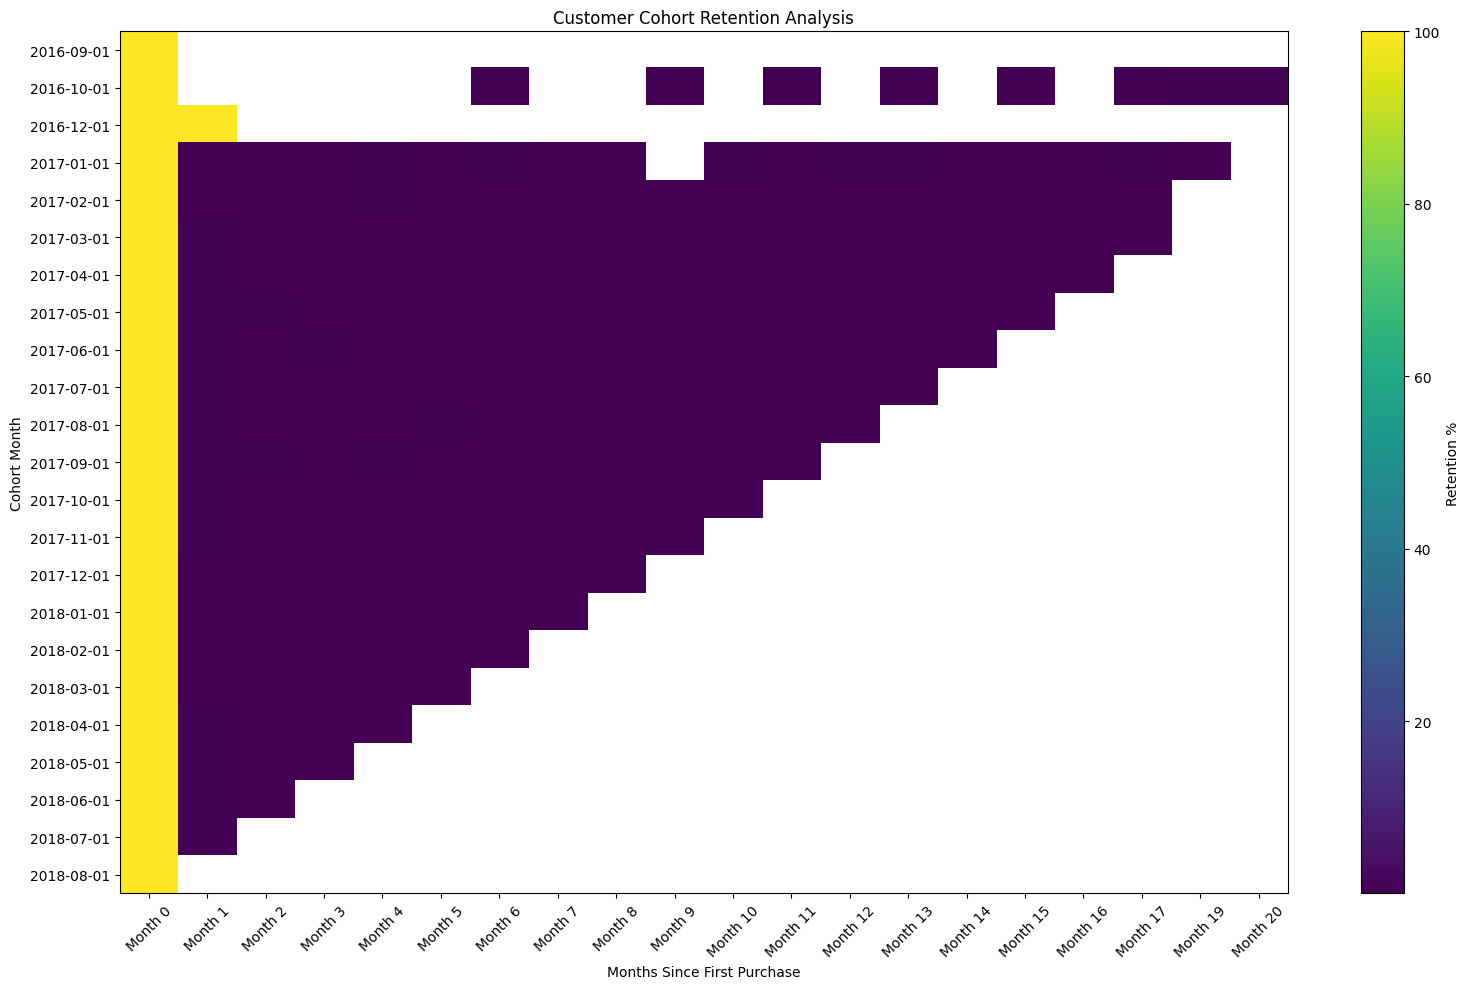

In [236]:
plt.figure(figsize=(16, 10))

plt.imshow(
    retention_table,
    aspect="auto"
)

plt.colorbar(label="Retention %")

plt.xticks(
    range(len(retention_table.columns)),
    retention_table.columns,
    rotation=45
)

plt.yticks(
    range(len(retention_table.index)),
    retention_table.index.astype(str)
)

plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.title("Customer Cohort Retention Analysis")

plt.tight_layout()
plt.show()

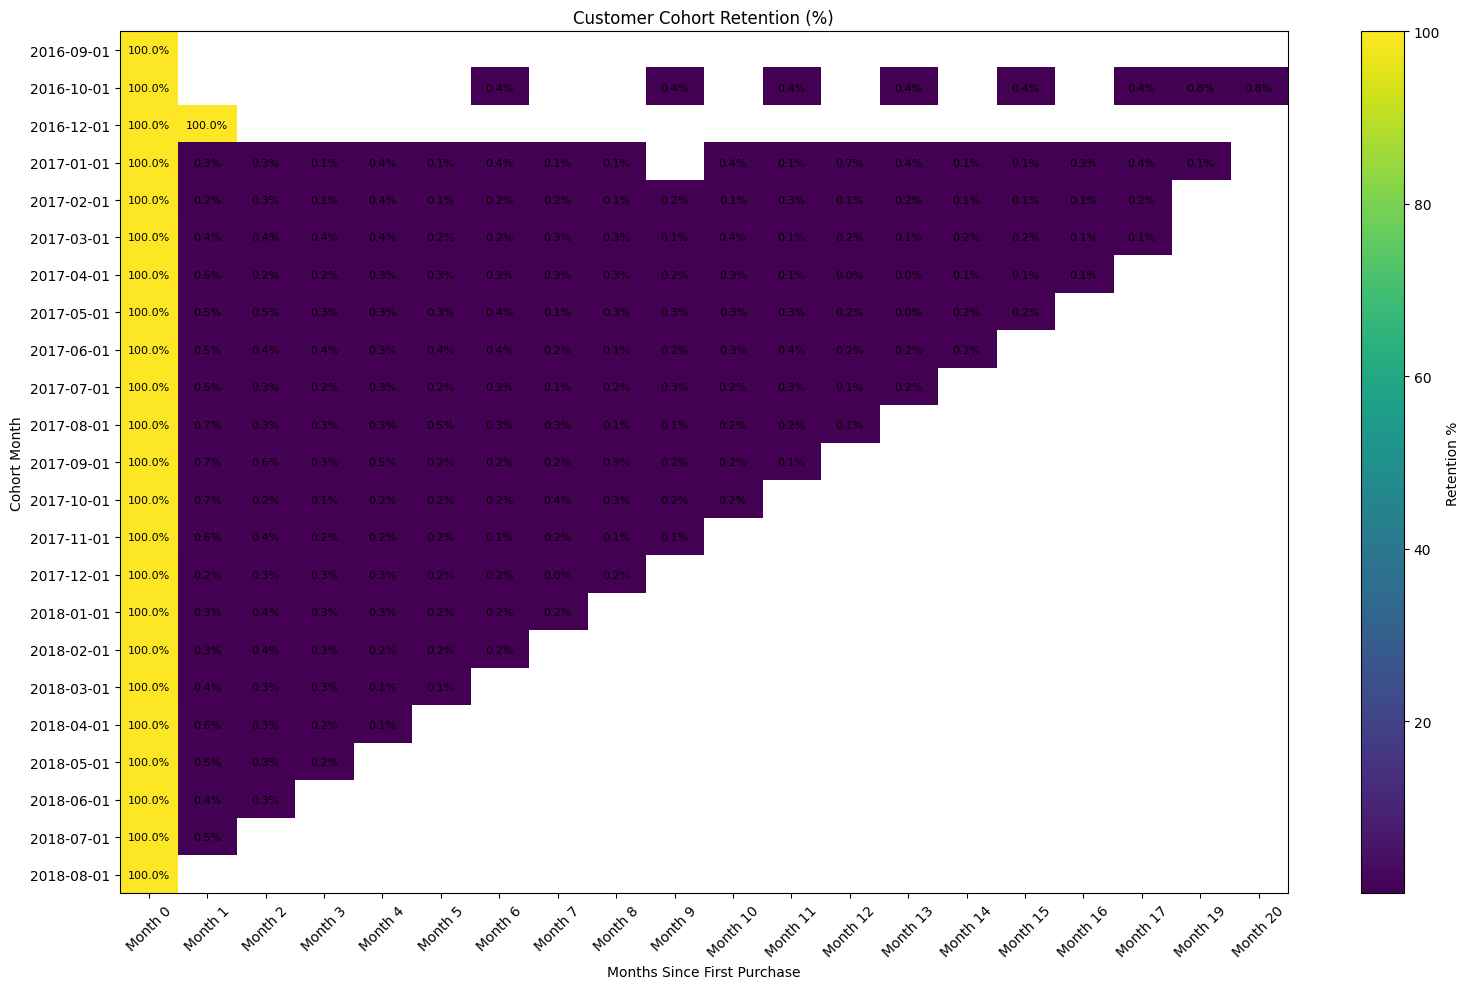

In [237]:
plt.figure(figsize=(16, 10))

plt.imshow(
    retention_table,
    aspect="auto"
)

plt.colorbar(label="Retention %")

plt.xticks(
    range(len(retention_table.columns)),
    retention_table.columns,
    rotation=45
)

plt.yticks(
    range(len(retention_table.index)),
    retention_table.index.astype(str)
)

for i in range(retention_table.shape[0]):
    for j in range(retention_table.shape[1]):
        value = retention_table.iloc[i, j]
        
        if not pd.isna(value):
            plt.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=8
            )

plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.title("Customer Cohort Retention (%)")

plt.tight_layout()
plt.show()

In [238]:
month_1_retention = retention_table['Month 1']

month_1_retention

cohort_month
2016-09-01       NaN
2016-10-01       NaN
2016-12-01    100.00
2017-01-01      0.28
2017-02-01      0.18
2017-03-01      0.44
2017-04-01      0.62
2017-05-01      0.46
2017-06-01      0.49
2017-07-01      0.53
2017-08-01      0.69
2017-09-01      0.70
2017-10-01      0.72
2017-11-01      0.57
2017-12-01      0.21
2018-01-01      0.34
2018-02-01      0.35
2018-03-01      0.40
2018-04-01      0.59
2018-05-01      0.52
2018-06-01      0.43
2018-07-01      0.52
2018-08-01       NaN
Name: Month 1, dtype: float64

In [239]:
avg_month_1_retention = month_1_retention.mean()

print(
    f"Average month 1 retention: "
    f"{avg_month_1_retention:.2f}%"
)

Average month 1 retention: 5.45%


In [240]:
month_3_retention = retention_table["Month 3"]

month_3_retention

cohort_month
2016-09-01     NaN
2016-10-01     NaN
2016-12-01     NaN
2017-01-01    0.14
2017-02-01    0.12
2017-03-01    0.40
2017-04-01    0.18
2017-05-01    0.29
2017-06-01    0.43
2017-07-01    0.24
2017-08-01    0.27
2017-09-01    0.27
2017-10-01    0.09
2017-11-01    0.17
2017-12-01    0.34
2018-01-01    0.29
2018-02-01    0.30
2018-03-01    0.30
2018-04-01    0.24
2018-05-01    0.18
2018-06-01     NaN
2018-07-01     NaN
2018-08-01     NaN
Name: Month 3, dtype: float64

In [241]:
avg_month_3_retention = month_3_retention.mean()

print(
    f"Average month 3 retention: "
    f"{avg_month_3_retention:.2f}%"
)

Average month 3 retention: 0.25%


In [242]:
month_6_retention = retention_table["Month 6"]

month_6_retention

cohort_month
2016-09-01     NaN
2016-10-01    0.38
2016-12-01     NaN
2017-01-01    0.42
2017-02-01    0.25
2017-03-01    0.16
2017-04-01    0.35
2017-05-01    0.41
2017-06-01    0.36
2017-07-01    0.32
2017-08-01    0.30
2017-09-01    0.22
2017-10-01    0.21
2017-11-01    0.11
2017-12-01    0.17
2018-01-01    0.18
2018-02-01    0.21
2018-03-01     NaN
2018-04-01     NaN
2018-05-01     NaN
2018-06-01     NaN
2018-07-01     NaN
2018-08-01     NaN
Name: Month 6, dtype: float64

In [243]:
avg_month_6_retention = month_6_retention.mean()

print(
    f"Average month 6 retention: "
    f"{avg_month_6_retention:.2f}%"
)

Average month 6 retention: 0.27%


In [244]:
cohort_sizes = (
    customer_order
    .groupby("cohort_month")["customer_unique_id"]
    .nunique()
    .sort_index()
)

cohort_sizes

cohort_month
2016-09-01       1
2016-10-01     262
2016-12-01       1
2017-01-01     717
2017-02-01    1628
2017-03-01    2503
2017-04-01    2256
2017-05-01    3451
2017-06-01    3037
2017-07-01    3752
2017-08-01    4057
2017-09-01    4004
2017-10-01    4328
2017-11-01    7060
2017-12-01    5338
2018-01-01    6842
2018-02-01    6288
2018-03-01    6774
2018-04-01    6582
2018-05-01    6506
2018-06-01    5878
2018-07-01    5949
2018-08-01    6144
Name: customer_unique_id, dtype: int64

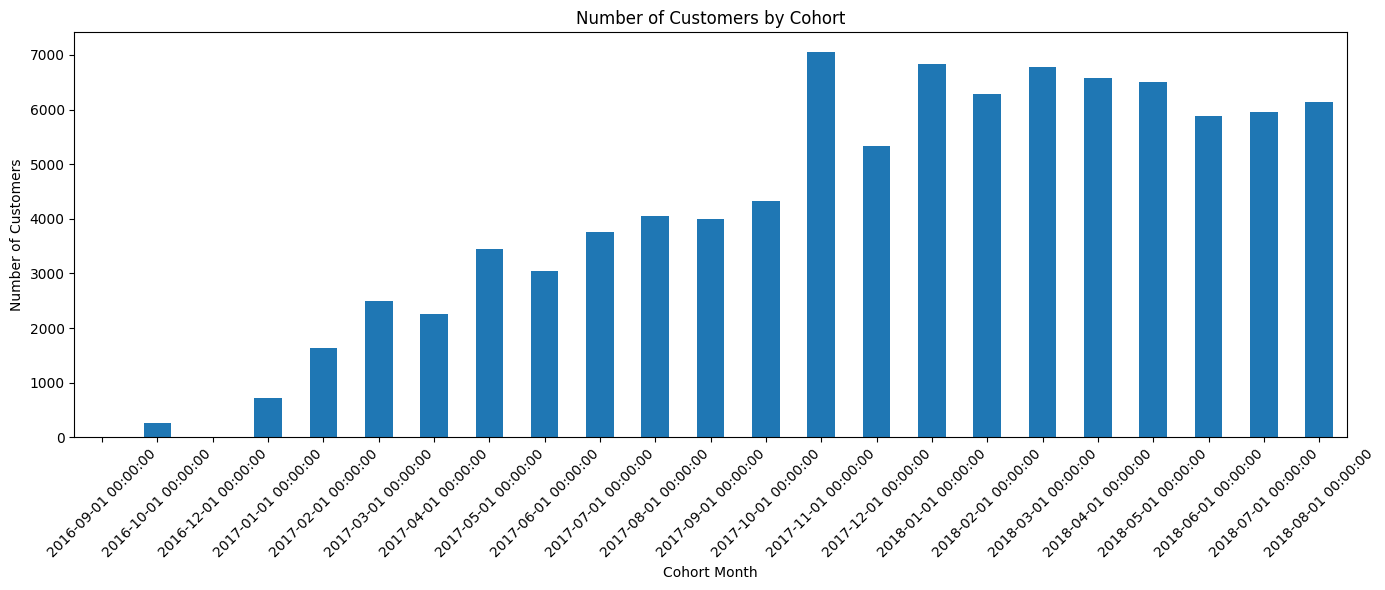

In [245]:
plt.figure(figsize=(14, 6))

cohort_sizes.plot(kind="bar")

plt.title("Number of Customers by Cohort")
plt.xlabel("Cohort Month")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [246]:
purchase_frequency = (
    customer_order
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

purchase_frequency

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
                                   ..
fffcf5a5ff07b0908bd4e2dbc735a684    1
fffea47cd6d3cc0a88bd621562a9d061    1
ffff371b4d645b6ecea244b27531430a    1
ffff5962728ec6157033ef9805bacc48    1
ffffd2657e2aad2907e67c3e9daecbeb    1
Name: order_id, Length: 93358, dtype: int64

In [247]:
purchase_frequency.value_counts().sort_index()

order_id
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [248]:
total_customers = purchase_frequency.shape[0]

repeat_customers = (
    purchase_frequency > 1
).sum()

repeat_purchase_rate = (
    repeat_customers / total_customers
) * 100

print(f"Total customers: {total_customers:,}")
print(f"Repeat customers: {repeat_customers:,}")
print(f"Repeat purchase rate: {repeat_purchase_rate:.2f}%")

Total customers: 93,358
Repeat customers: 2,801
Repeat purchase rate: 3.00%


In [249]:
order_revenue = (
    order_payment
    .groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
)
order_revenue

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,343.40
99436,fffcd46ef2263f404302a634eb57f7eb,386.53
99437,fffce4705a9662cd70adb13d4a31832d,116.85
99438,fffe18544ffabc95dfada21779c9644f,64.71


In [250]:
customer_order_revenue=pd.merge(customer_order,order_revenue, on="order_id", how="left")

customer_order_revenue

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month,cohort_month,cohort_index,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10-01,2017-09-01,1,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07-01,2018-07-01,0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08-01,2018-08-01,0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11-01,2017-11-01,0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02-01,2018-02-01,0,28.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,2017-03-01,2017-03-01,0,85.08
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,2018-02-01,2018-02-01,0,195.00
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,2017-08-01,2017-08-01,0,271.01
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2018-01-01,2018-01-01,0,441.16


In [251]:
customer_order_revenue[[ "order_id",
        "customer_unique_id",
        "cohort_month",
        "cohort_index",
        "payment_value"]].head(6)

,order_id,customer_unique_id,cohort_month,cohort_index,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-09-01,1,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-01,0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-01,0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,0,28.62
5,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,2017-07-01,0,175.26


In [252]:
revenue_cohort = (
    customer_order_revenue
    .groupby(["cohort_month", "cohort_index"])
    ["payment_value"]
    .sum()
    .reset_index())

revenue_cohort.head(6)

,cohort_month,cohort_index,payment_value
0,2016-09-01,0,0.00
1,2016-10-01,0,46566.71
2,2016-10-01,6,111.30
3,2016-10-01,9,356.13
4,2016-10-01,11,56.78
5,2016-10-01,13,163.53


In [253]:
revenue_table = revenue_cohort.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="payment_value"
)

revenue_table.head(6)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,46566.71,NaN,NaN,NaN,NaN,NaN,111.30,NaN,NaN,356.13,NaN,56.78,NaN,163.53,NaN,381.00,NaN,116.57,384.01,181.37
2016-12-01,19.62,19.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,127526.05,111.07,114.70,89.70,246.25,69.33,448.43,105.17,47.05,NaN,427.05,66.60,552.45,351.65,93.70,104.61,219.35,354.43,50.93,NaN
2017-02-01,271187.58,481.68,570.63,118.73,1151.96,74.21,688.92,274.30,464.61,385.35,343.22,454.39,279.24,397.11,181.66,136.79,291.68,369.65,NaN,NaN
2017-03-01,413773.01,1623.63,1737.12,1836.10,1213.97,1433.39,689.18,887.42,1385.61,237.96,725.93,380.30,907.29,238.58,687.41,717.55,203.88,308.56,NaN,NaN


In [254]:
revenue_retention = revenue_table.divide(
    revenue_table.iloc[:, 0],
    axis=0
) * 100

revenue_retention.head(6)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,100.0,NaN,NaN,NaN,NaN,NaN,0.239012,NaN,NaN,0.764774,NaN,0.121933,NaN,0.351174,NaN,0.818181,NaN,0.250329,0.824645,0.389484
2016-12-01,100.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,100.0,0.087096,0.089942,0.070339,0.193098,0.054365,0.351638,0.082469,0.036894,NaN,0.334873,0.052225,0.433206,0.275748,0.073475,0.082030,0.172004,0.277928,0.039937,NaN
2017-02-01,100.0,0.177619,0.210419,0.043782,0.424783,0.027365,0.254038,0.101148,0.171324,0.142097,0.126562,0.167556,0.102969,0.146434,0.066987,0.050441,0.107557,0.136308,NaN,NaN
2017-03-01,100.0,0.392396,0.419824,0.443746,0.293390,0.346419,0.166560,0.214470,0.334872,0.057510,0.175442,0.091910,0.219272,0.057660,0.166132,0.173416,0.049273,0.074572,NaN,NaN


In [255]:
revenue_retention=revenue_retention.round(2)

revenue_retention.head(6)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,100.0,NaN,NaN,NaN,NaN,NaN,0.24,NaN,NaN,0.76,NaN,0.12,NaN,0.35,NaN,0.82,NaN,0.25,0.82,0.39
2016-12-01,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,100.0,0.09,0.09,0.07,0.19,0.05,0.35,0.08,0.04,NaN,0.33,0.05,0.43,0.28,0.07,0.08,0.17,0.28,0.04,NaN
2017-02-01,100.0,0.18,0.21,0.04,0.42,0.03,0.25,0.10,0.17,0.14,0.13,0.17,0.10,0.15,0.07,0.05,0.11,0.14,NaN,NaN
2017-03-01,100.0,0.39,0.42,0.44,0.29,0.35,0.17,0.21,0.33,0.06,0.18,0.09,0.22,0.06,0.17,0.17,0.05,0.07,NaN,NaN


In [256]:
order_product = pd.merge(orders_items,product_dataset, on="product_id",how="left")

order_product.head(6)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69,utilidades_domesticas,36.0,558.0,1.0,450.0,24.0,8.0,15.0


In [257]:
order_product=pd.merge(order_product,category_translation, on="product_category_name",how="left")

order_product.head(6)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69,utilidades_domesticas,36.0,558.0,1.0,450.0,24.0,8.0,15.0,housewares


In [259]:
order_product_customer = pd.merge(order_product,customer_order[["order_id","customer_unique_id","cohort_month","cohort_index"]], on="order_id",how="inner")

order_product_customer.head(6)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,cohort_month,cohort_index
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,871766c5855e863f6eccc05f988b23cb,2017-09-01,0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,eb28e67c4c0b83846050ddfb8a35d051,2017-04-01,0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,3818d81c6709e39d06b2738a8d3a2474,2018-01-01,0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,af861d436cfc08b2c2ddefd0ba074622,2018-08-01,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,64b576fb70d441e8f1b2d7d446e483c5,2017-02-01,0
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69,utilidades_domesticas,36.0,558.0,1.0,450.0,24.0,8.0,15.0,housewares,85c835d128beae5b4ce8602c491bf385,2017-05-01,0


In [260]:
first_purchase_categories=(order_product_customer[order_product_customer["cohort_index"]==0]
    .groupby("product_category_name_english")["customer_unique_id"].nunique().sort_values(ascending= False))

first_purchase_categories.head(6)

product_category_name_english
bed_bath_table           8880
health_beauty            8416
sports_leisure           7257
computers_accessories    6331
furniture_decor          6092
housewares               5582
Name: customer_unique_id, dtype: int64

In [261]:
customer_order.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month,cohort_month,cohort_index
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10-01,2017-09-01,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07-01,2018-07-01,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08-01,2018-08-01,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11-01,2017-11-01,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02-01,2018-02-01,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,2017-07-01,2017-07-01,0


In [262]:
state_cohort=(customer_order.groupby(["customer_state","cohort_index"])["customer_unique_id"].nunique().reset_index())

state_cohort.head(6)

,customer_state,cohort_index,customer_unique_id
0,AC,0,76
1,AC,2,1
2,AC,3,1
3,AC,10,1
4,AL,0,387
5,AL,1,1


In [263]:
state_retention=state_cohort.pivot(
    index="customer_state",
    columns="cohort_index",
    values="customer_unique_id"
)

state_retention.head(6)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
customer_state,,,,,,,,,,,,,,,,,,,,
AC,76.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AL,387.0,1.0,NaN,NaN,NaN,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AM,140.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
AP,66.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BA,3158.0,17.0,6.0,4.0,4.0,5.0,7.0,3.0,2.0,NaN,1.0,2.0,2.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN
CE,1257.0,3.0,4.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [264]:
customer_order.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month,cohort_month,cohort_index
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10-01,2017-09-01,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07-01,2018-07-01,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08-01,2018-08-01,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11-01,2017-11-01,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02-01,2018-02-01,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,2017-07-01,2017-07-01,0


In [265]:
customer_summary = (
    customer_order
    .groupby("customer_unique_id")
    .agg(
        first_purchase_date=(
            "order_purchase_timestamp",
            "min"
        ),
        last_purchase_date=(
            "order_purchase_timestamp",
            "max"
        ),
        total_orders=("order_id", "nunique"),
        customer_city=("customer_city", "first"),
        customer_state=("customer_state", "first"),
        cohort_month=("cohort_month", "first")
    )
    .reset_index()
)

customer_summary.head(6)

,customer_unique_id,first_purchase_date,last_purchase_date,total_orders,customer_city,customer_state,cohort_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,cajamar,SP,2018-05-01
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,osasco,SP,2018-05-01
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,sao jose,SC,2017-03-01
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,belem,PA,2017-10-01
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,sorocaba,SP,2017-11-01
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04-05 19:33:16,2018-04-05 19:33:16,1,sao paulo,SP,2018-04-01


In [266]:
customer_summary["first_purchase_date"] = pd.to_datetime(
    customer_summary["first_purchase_date"]
)

customer_summary["last_purchase_date"] = pd.to_datetime(
    customer_summary["last_purchase_date"]
)

customer_summary["lifetime_months"] = (
    (
        customer_summary["last_purchase_date"].dt.year -
        customer_summary["first_purchase_date"].dt.year
    ) * 12
    +
    (
        customer_summary["last_purchase_date"].dt.month -
        customer_summary["first_purchase_date"].dt.month
    )
)

customer_summary.head(6)

,customer_unique_id,first_purchase_date,last_purchase_date,total_orders,customer_city,customer_state,cohort_month,lifetime_months
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,cajamar,SP,2018-05-01,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,osasco,SP,2018-05-01,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,sao jose,SC,2017-03-01,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,belem,PA,2017-10-01,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,sorocaba,SP,2017-11-01,0
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04-05 19:33:16,2018-04-05 19:33:16,1,sao paulo,SP,2018-04-01,0


In [267]:
retention_table.to_csv("customer_cohort_retention.csv")

In [268]:
customer_summary.to_csv("customer_cohort_summary.csv",index=False)

In [269]:
revenue_retention.to_csv("revenue_cohort_retention.csv")

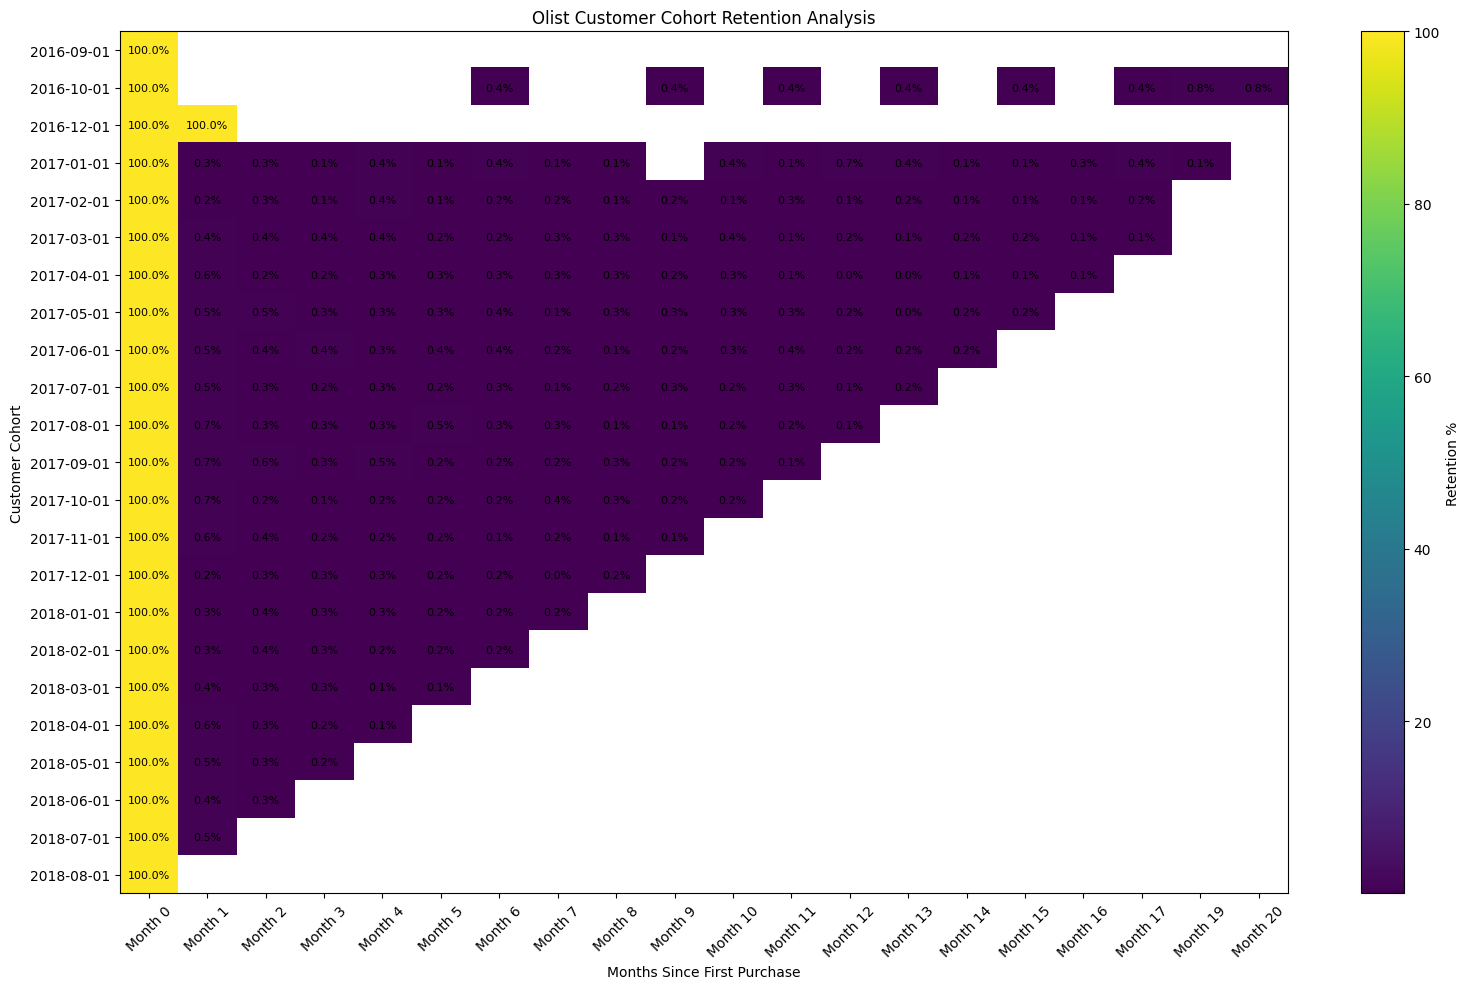

In [270]:
plt.figure(figsize=(16, 10))

plt.imshow(
    retention_table,
    aspect="auto"
)

plt.colorbar(label="Retention %")

plt.xticks(
    range(len(retention_table.columns)),
    retention_table.columns,
    rotation=45
)

plt.yticks(
    range(len(retention_table.index)),
    retention_table.index.astype(str)
)

for i in range(retention_table.shape[0]):
    for j in range(retention_table.shape[1]):
        value = retention_table.iloc[i, j]

        if not pd.isna(value):
            plt.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=8
            )

plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort")
plt.title("Olist Customer Cohort Retention Analysis")

plt.tight_layout()
plt.show()